In [44]:
import numpy as np
import pandas as pd
import zarr
import cv2 as cv

import s3fs
import boto3
import sagemaker

from src.utils import *

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
%store -r
%store

Stored variables and their in-db values:
default_bucket                -> 'sagemaker-us-east-1-298748835671'
s3_project_prefix             -> 's3://sagemaker-us-east-1-298748835671/floorplan-g
s3_project_root               -> 'floorplan-generator'


In [3]:
sns.set_theme()

sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
s3 = boto3.client("s3")

s3_project_prefix = f"s3://{default_bucket}/{s3_project_root}"

In [4]:
%store s3_project_prefix

Stored 's3_project_prefix' (str)


In [5]:
s3.download_file(default_bucket, "floorplan-generator/metadata/metadata.parquet", "metadata.parquet")

metadata_df = pd.read_parquet("metadata.parquet")
metadata_df.shape

(80788, 10)

In [6]:
metadata_df.tail()

,sample_id,0,1,2,3,4,5,6,7,id
80783,sample_80783,"{'category': 0, 'centroid': [72, 143]}","{'category': 2, 'centroid': [44, 169]}","{'category': 11, 'centroid': [44, 208]}","{'category': 1, 'centroid': [156, 99]}","{'category': 3.0, 'centroid': [108, 70]}","{'category': 3.0, 'centroid': [101, 202]}","{'category': 9.0, 'centroid': [215, 74]}",None,9973.pkl
80784,sample_80784,"{'category': 9, 'centroid': [51, 52]}","{'category': 2, 'centroid': [51, 90]}","{'category': 7, 'centroid': [60, 192]}","{'category': 6, 'centroid': [75, 139]}","{'category': 0.0, 'centroid': [134, 123]}","{'category': 3.0, 'centroid': [106, 201]}","{'category': 1.0, 'centroid': [158, 193]}","{'category': 9.0, 'centroid': [210, 134]}",9983.pkl
80785,sample_80785,"{'category': 7, 'centroid': [74, 162]}","{'category': 9, 'centroid': [63, 78]}","{'category': 0, 'centroid': [131, 112]}","{'category': 2, 'centroid': [87, 78]}","{'category': 3.0, 'centroid': [115, 178]}","{'category': 1.0, 'centroid': [159, 169]}","{'category': 9.0, 'centroid': [197, 107]}",None,9993.pkl
80786,sample_80786,"{'category': 0, 'centroid': [96, 123]}","{'category': 2, 'centroid': [73, 186]}","{'category': 9, 'centroid': [104, 186]}","{'category': 3, 'centroid': [127, 172]}","{'category': 1.0, 'centroid': [148, 80]}","{'category': 7.0, 'centroid': [165, 122]}","{'category': 7.0, 'centroid': [165, 163]}","{'category': 9.0, 'centroid': [191, 77]}",9996.pkl
80787,sample_80787,"{'category': 2, 'centroid': [66, 71]}","{'category': 9, 'centroid': [66, 110]}","{'category': 7, 'centroid': [77, 181]}","{'category': 3, 'centroid': [73, 145]}","{'category': 0.0, 'centroid': [129, 122]}","{'category': 1.0, 'centroid': [153, 178]}","{'category': 9.0, 'centroid': [196, 117]}",None,9999.pkl


s3://sagemaker-us-east-1-298748835671/floorplan-generator/metadata/metadata.parquet

In [ ]:
room_counter = lambda x: x.notna().sum()

room_freq = []

for i in range(metadata_df.shape[0]):
    centroids = metadata_df.iloc[i, 1:-1]
    rooms = room_counter(centroids)
    room_freq.append(rooms)

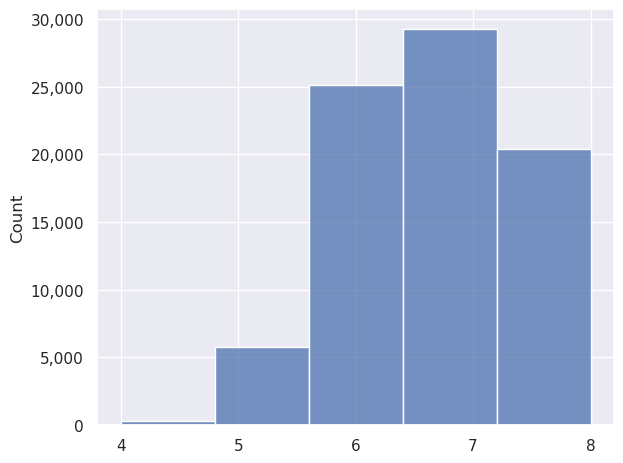

In [89]:
fig, ax = plt.subplots()

sns.histplot(room_freq, ax=ax, bins=5)

ax.set_xticks([4, 5, 6, 7, 8])
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

# Visualizing All Layers Stacked

In [90]:
# Get room vocab
vocab = get_vocab()
room_index = vocab["object_idx_to_name"]
room_index

['LivingRoom',
 'MasterRoom',
 'Kitchen',
 'Bathroom',
 'DiningRoom',
 'ChildRoom',
 'StudyRoom',
 'SecondRoom',
 'GuestRoom',
 'Balcony',
 'Entrance',
 'Storage',
 'Wall-in',
 'External',
 'ExteriorWall']

In [ ]:
# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=f'{s3_project_prefix}/store/data.zarr', s3=fs, check=False)

# Open the zarr array or group
z = zarr.open(store, mode='r')

i = 72

# Load sample
boundary_mask = z['boundary_masks'][i]
inside_mask = z['inside_masks'][i]
room_mask = z['room_masks'][i]
door_mask = z['door_masks'][i]
edge_totals = z['edge_totals'][i]
edge_index = z['edge_index'][i]
edge_attr = z['edge_attr'][i]
node_features = z['node_features'][i]
node_labels = z['node_labels'][i]
node_totals = z['node_totals'][i]

metadata = metadata_df.iloc[i, 1:-1]

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7efd1f29e8d0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7efd1f2f4e30>, 6969.928495074)])']
connector: <aiohttp.connector.TCPConnector object at 0x7efd1f29e8a0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7efd1f39fa10>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7efd1f2f4bf0>, 6969.924773702)])']
connector: <aiohttp.connector.TCPConnector object at 0x7efd251a44a0>


In [8]:
def get_label(x):
    if x:
        return x["category"]
    else:
        pass

col_0 = metadata_df["0"].apply(get_label)
col_1 = metadata_df["1"].apply(get_label)
col_2 = metadata_df["2"].apply(get_label)
col_3 = metadata_df["3"].apply(get_label)
col_4 = metadata_df["4"].apply(get_label)
col_5 = metadata_df["5"].apply(get_label)
col_6 = metadata_df["6"].apply(get_label)
col_7 = metadata_df["7"].apply(get_label)

all_labels = pd.concat([col_0, col_1, col_2, col_3, col_4, col_5, col_6, col_7])

In [9]:
df = pd.DataFrame(all_labels, columns=["col"])
category_counts = df["col"].value_counts().sort_index()
print(category_counts)

class_weights = 1.0 / category_counts
CLASS_WEIGHTS = class_weights / class_weights.sum()

col
0.0     80788
1.0     80466
2.0     77768
3.0     97113
4.0      1312
5.0      3928
6.0     14985
7.0     99987
8.0       860
9.0     86545
10.0      292
11.0     3351
12.0     1043
Name: count, dtype: int64


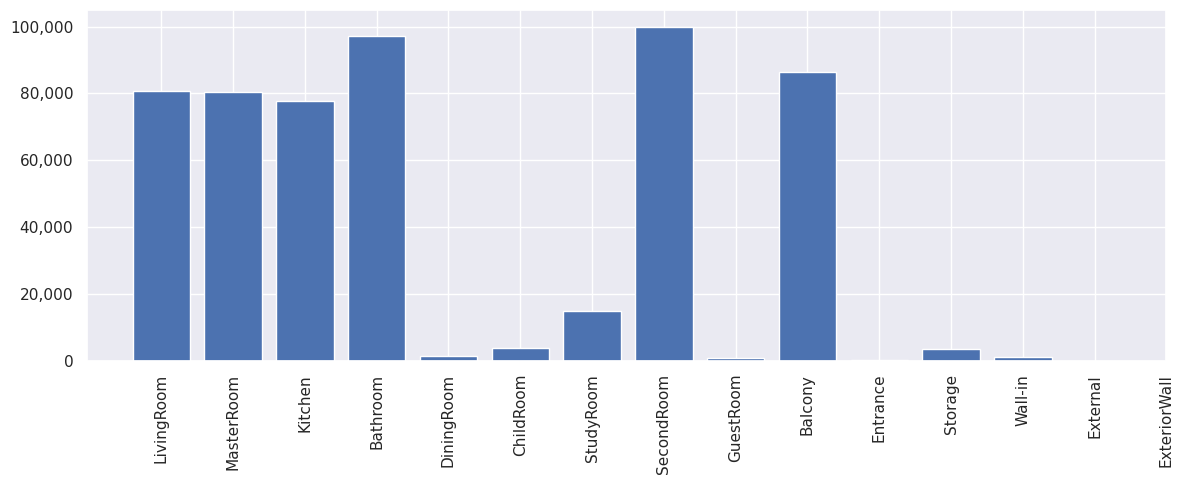

In [88]:
# Visualizing Class Distribution

fig, ax = plt.subplots(figsize=(12,5))

ax.bar(category_counts.index, category_counts)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.set_xticks(range(len(room_index)))
ax.set_xticklabels(room_index, rotation=90)

plt.tight_layout()
plt.show()

In [112]:
type_per_plan = pd.DataFrame({"room_type": room_index[:-2],
                              "avg_per_plan": category_counts/metadata_df.shape[0]})

type_per_plan["avg_per_plan"] = type_per_plan["avg_per_plan"].apply(lambda x: f"{x:.2f}")
type_per_plan

,room_type,avg_per_plan
col,,
0.0,LivingRoom,1.00
1.0,MasterRoom,1.00
2.0,Kitchen,0.96
3.0,Bathroom,1.20
4.0,DiningRoom,0.02
5.0,ChildRoom,0.05
6.0,StudyRoom,0.19
7.0,SecondRoom,1.24
8.0,GuestRoom,0.01


# Visualizing Floorplans

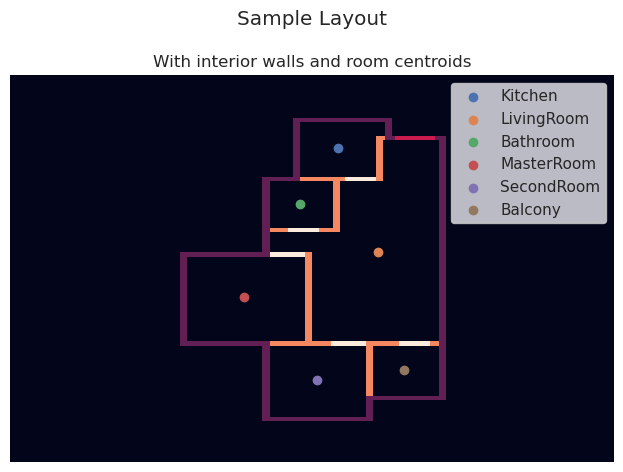

In [10]:
# recovering walls through elementise addition
fig, ax = plt.subplots()

stacked_layers = stack_normalize(boundary_mask, room_mask, door_mask)
sns.heatmap(stacked_layers, 
            cbar=False, xticklabels=False, yticklabels=False)

for room in metadata:
    if room:
        ax.scatter(
            room["centroid"][1], 
            room["centroid"][0],
            label=room_index[int(room["category"])]
            )

ax.set_title("With interior walls and room centroids")
ax.legend()

plt.suptitle("Sample Layout")
plt.tight_layout()
plt.show()

# Visualizing Individual Masks (Channels)

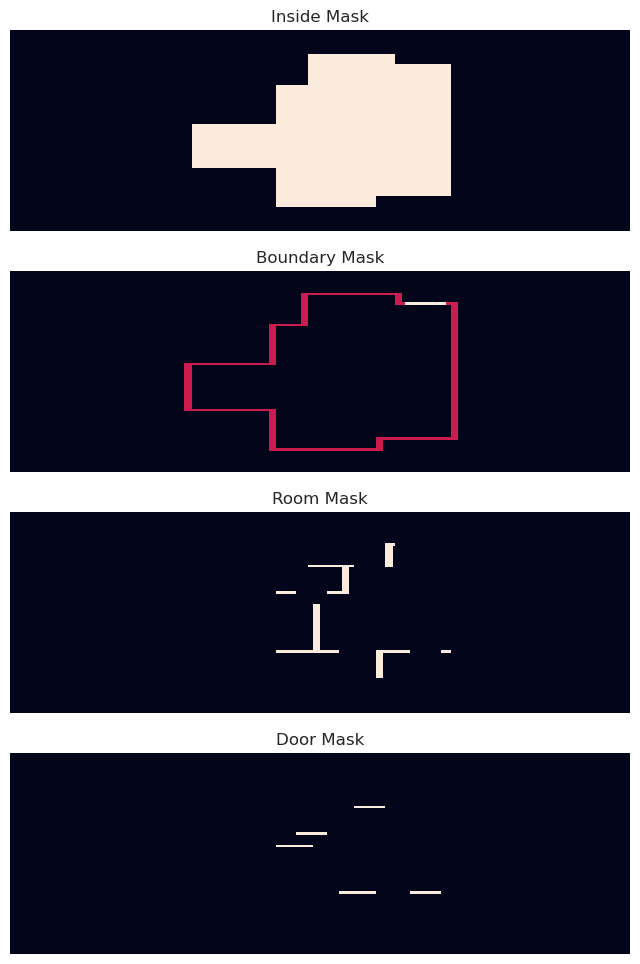

In [11]:
masks = [inside_mask, boundary_mask, room_mask, door_mask]

fig, ax = plt.subplots(len(masks), figsize=(8, 12))

for i, mask in enumerate(masks):
    sns.heatmap(mask, ax=ax[i], cbar=False, xticklabels=False, yticklabels=False)

ax[0].set_title("Inside Mask")
ax[1].set_title("Boundary Mask")
ax[2].set_title("Room Mask")
ax[3].set_title("Door Mask")

plt.show()

# Graph Extraction Process

<Axes: >

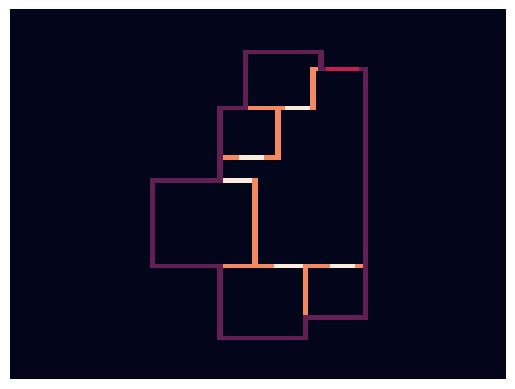

In [12]:
sns.heatmap(stacked_layers, xticklabels=False, yticklabels=False, cbar=False)

<Axes: >

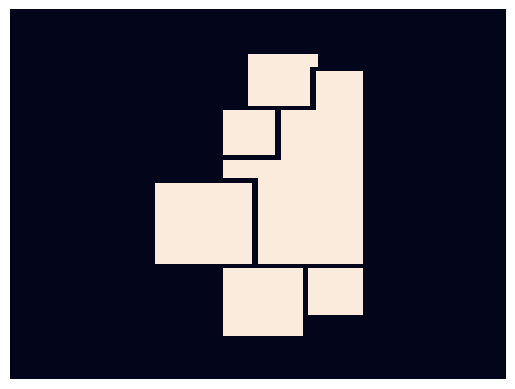

In [13]:
stacked_layers_bin = stack_binarize(stacked_layers)
negative = negative_space(stacked_layers_bin, inside_mask)

sns.heatmap(negative, xticklabels=False, yticklabels=False, cbar=False)

In [14]:
num_labels, labels, stats, centroids = conn_components(inside_mask, 
                                                       boundary_mask, 
                                                       room_mask, 
                                                       door_mask)

num_labels

7

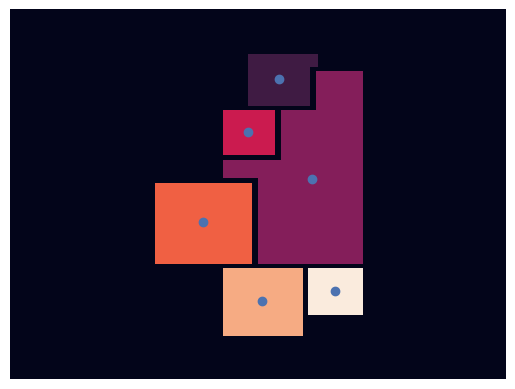

In [15]:
fig, ax = plt.subplots()

sns.heatmap(labels, xticklabels=False, yticklabels=False, cbar=False, ax=ax)
ax.scatter(centroids[1:,0], centroids[1:,1])

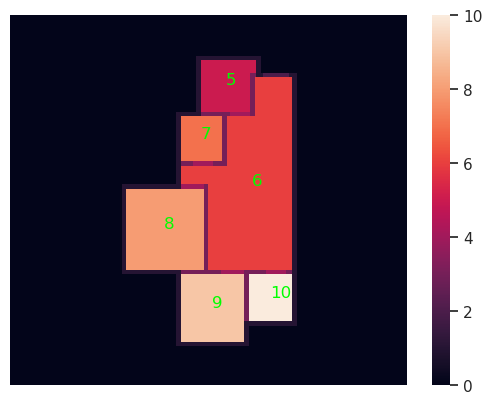

In [16]:
fig, ax = plt.subplots()

rwb = rooms_with_bounds(stacked_layers, labels)

sns.heatmap(rwb, xticklabels=False, yticklabels=False, cbar=True, ax=ax)

for i, centroid in enumerate(centroids[1:, :]):
    ax.text(centroid[0], centroid[1], f"{i+5}", color="lime")

In [17]:
centroids.shape

(7, 2)

In [18]:
stats_cols = ["left", "top", "width", "height", "area"]
pd.DataFrame(stats, columns=stats_cols)

,left,top,width,height,area
0,0,0,256,256,51662
1,123,31,36,36,1188
2,110,43,72,133,6198
3,110,70,27,31,837
4,75,120,50,56,2800
5,110,179,41,47,1927
6,154,179,28,33,924


In [19]:
adj_graph = extract_all_adjacencies(rwb)
adj_graph

,n1,n2,adj_type,edge_strength
1,5,6,1,12
2,5,7,0,5
3,6,7,0,36
4,6,8,0,56
6,6,9,1,9
8,6,10,1,13
9,9,10,0,33


In [20]:
metadata

0       {'category': 2, 'centroid': [48, 139]}
1      {'category': 0, 'centroid': [117, 156]}
2       {'category': 3, 'centroid': [85, 123]}
3       {'category': 1, 'centroid': [147, 99]}
4    {'category': 7.0, 'centroid': [202, 130]}
5    {'category': 9.0, 'centroid': [195, 167]}
6                                         None
7                                         None
Name: 72, dtype: object

In [21]:
centroids

array([[124.58611746, 126.15080717],
       [139.04545455,  48.09090909],
       [156.09148112, 117.44530494],
       [123.        ,  85.        ],
       [ 99.5       , 147.5       ],
       [130.        , 202.        ],
       [167.5       , 195.        ]])

In [22]:
categories = join_meta_category(centroids[1:, :], metadata)

/home/sagemaker-user/Generative-Interior-Synthesis/src/utils.py:234: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  categories.append(int(metadata_row[np.argmin(dists)]["category"]))


In [23]:
categories

[2, 0, 3, 1, 7, 9]

In [24]:
node_totals

array([6])

In [25]:
node_labels[:node_totals[0]]

array([2, 0, 3, 1, 7, 9])

In [26]:
node_features[:node_totals[0], :]

array([[ 139.04545455,   48.09090909, 1188.        ],
       [ 156.09148112,  117.44530494, 6198.        ],
       [ 123.        ,   85.        ,  837.        ],
       [  99.5       ,  147.5       , 2800.        ],
       [ 130.        ,  202.        , 1927.        ],
       [ 167.5       ,  195.        ,  924.        ]])

In [27]:
edge_totals

array([7])

In [28]:
edge_index[:, :edge_totals[0]]

array([[ 5,  5,  6,  6,  6,  6,  9],
       [ 6,  7,  7,  8,  9, 10, 10]])